In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# folder to save exported PNG charts (a deliverable)
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

RAW = Path("../data/raw")

# load the datasets Day 3 needs
nav = pd.read_csv("../data/processed/nav_history_clean.csv", parse_dates=["date"])
funds = pd.read_csv(RAW / "01_fund_master.csv")
aum = pd.read_csv(RAW / "03_aum_by_fund_house.csv", parse_dates=["date"])

print("nav:", nav.shape)
print("funds:", funds.shape)
print("aum:", aum.shape)
nav.head()

nav: (46000, 3)
funds: (40, 15)
aum: (90, 5)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Chart1-NAV trend

In [2]:
fig = px.line(nav, x="date", y="nav", color="amfi_code",
              title="Daily NAV — All 40 Schemes (2022–2026)")
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green",
              opacity=0.08, line_width=0, annotation_text="2023 Bull Run")
fig.add_vrect(x0="2024-01-01", x1="2024-06-30", fillcolor="red",
              opacity=0.08, line_width=0, annotation_text="2024 Correction")
fig.update_layout(showlegend=False, height=500)
fig.write_image("../reports/charts/01_nav_trend.png")
fig.show()

## Chart2-AUM bar

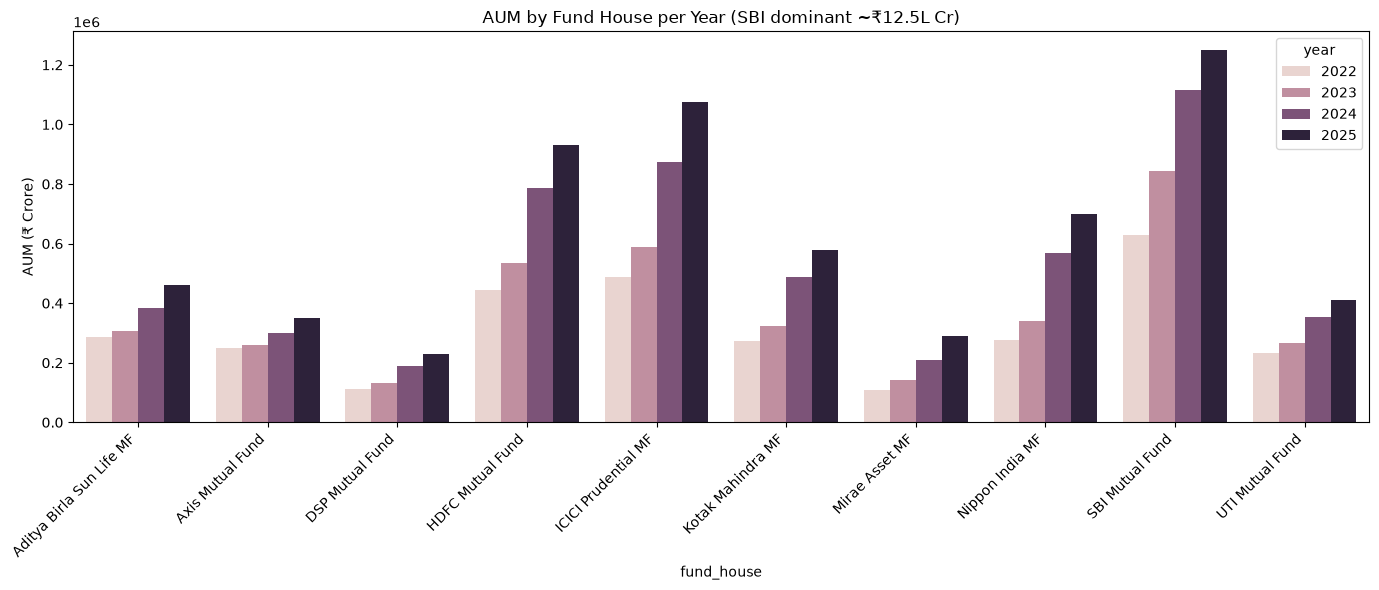

In [3]:
aum["year"] = aum["date"].dt.year
aum_yearly = aum.groupby(["year", "fund_house"])["aum_crore"].max().reset_index()
plt.figure(figsize=(14, 6))
sns.barplot(data=aum_yearly, x="fund_house", y="aum_crore", hue="year")
plt.title("AUM by Fund House per Year (SBI dominant ~₹12.5L Cr)")
plt.xticks(rotation=45, ha="right"); plt.ylabel("AUM (₹ Crore)")
plt.tight_layout()
plt.savefig("../reports/charts/02_aum_growth.png", dpi=120)
plt.show()

## Chart 3-SIP Time series

In [5]:
sip = pd.read_csv(RAW / "04_monthly_sip_inflows.csv")
sip["month"] = pd.to_datetime(sip["month"])
fig = px.line(sip, x="month", y="sip_inflow_crore",
              title="Monthly SIP Inflows (Jan 2022 - Dec 2025)", markers=True)
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]
fig.add_annotation(x=str(peak["month"].date()), y=peak["sip_inflow_crore"],
                   text=f"All-time high: Rs {peak['sip_inflow_crore']:,.0f} Cr",
                   showarrow=True, arrowhead=2, ay=-40)
fig.update_layout(height=500)
fig.write_image("../reports/charts/03_sip_trend.png")
fig.show()

## Chart4-Category inflow

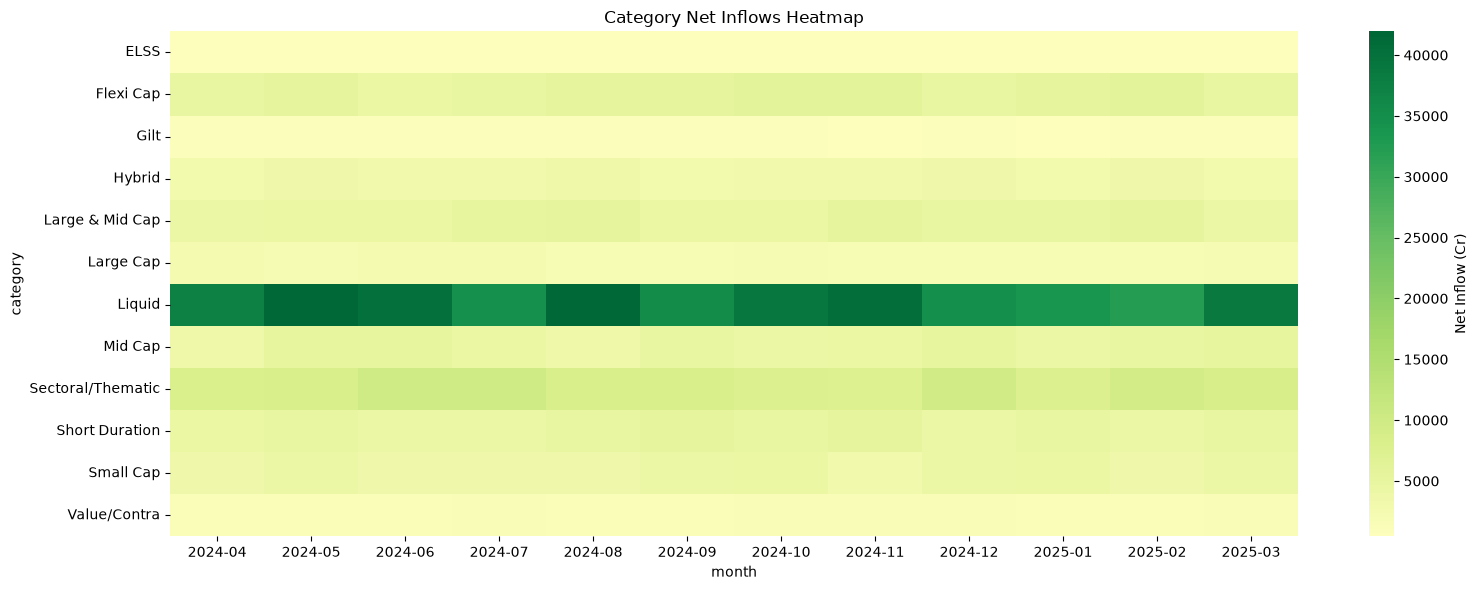

In [6]:
cat = pd.read_csv(RAW / "05_category_inflows.csv")
pivot = cat.pivot_table(index="category", columns="month",
                        values="net_inflow_crore", aggfunc="sum")
plt.figure(figsize=(16, 6))
sns.heatmap(pivot, cmap="RdYlGn", center=0, cbar_kws={"label": "Net Inflow (Cr)"})
plt.title("Category Net Inflows Heatmap")
plt.tight_layout()
plt.savefig("../reports/charts/04_category_heatmap.png", dpi=120)
plt.show()

## Chart 5 -Investor demographics

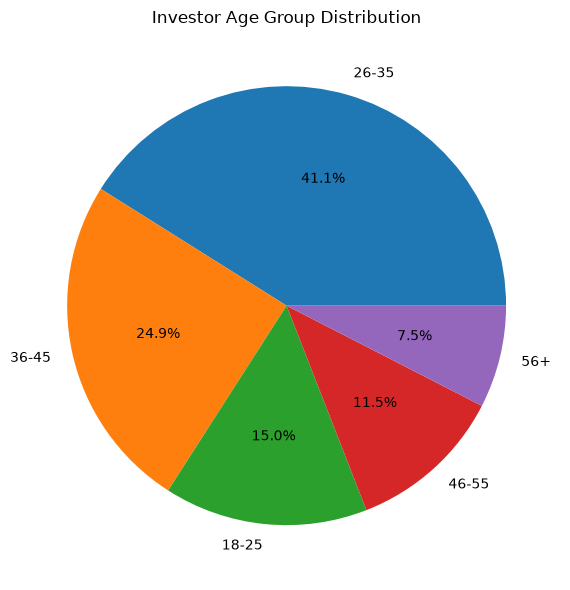

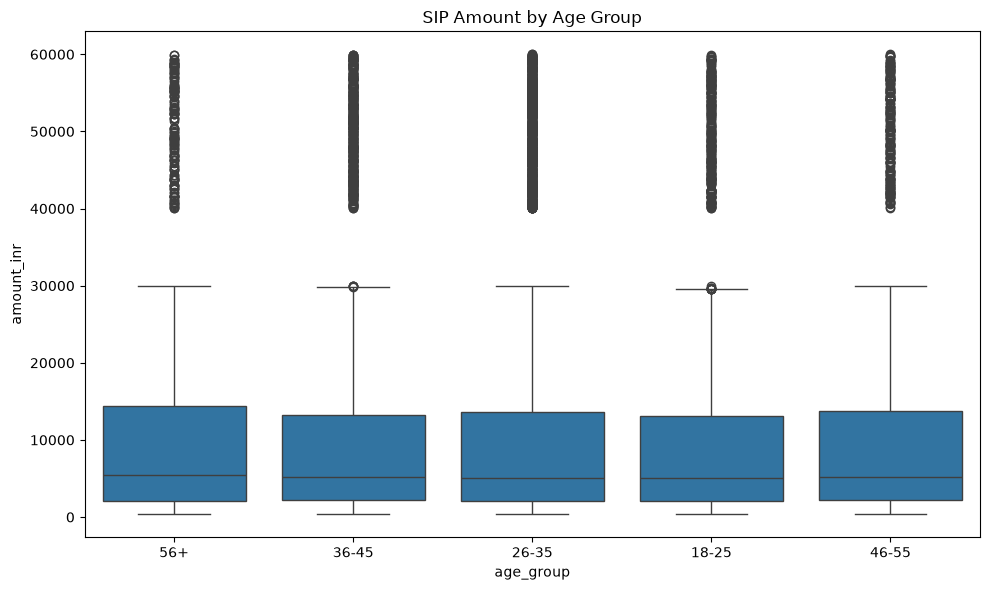

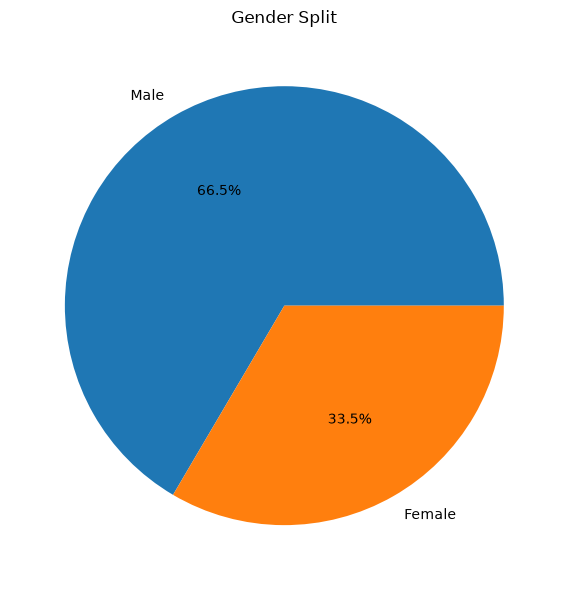

In [7]:
tx = pd.read_csv("../data/processed/investor_transactions_clean.csv")

# age group distribution pie
tx["age_group"].value_counts().plot.pie(autopct="%1.1f%%", figsize=(6,6),
    title="Investor Age Group Distribution")
plt.ylabel(""); plt.tight_layout()
plt.savefig("../reports/charts/05a_age_pie.png", dpi=120); plt.show()

# SIP amount box plot by age group
sip_tx = tx[tx["transaction_type"].str.contains("Sip", case=False, na=False)]
plt.figure(figsize=(10,6))
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr")
plt.title("SIP Amount by Age Group"); plt.tight_layout()
plt.savefig("../reports/charts/05b_sip_box.png", dpi=120); plt.show()

# gender split
tx["gender"].value_counts().plot.pie(autopct="%1.1f%%", figsize=(6,6),
    title="Gender Split")
plt.ylabel(""); plt.tight_layout()
plt.savefig("../reports/charts/05c_gender.png", dpi=120); plt.show()

## Chart6-Geographic distribution

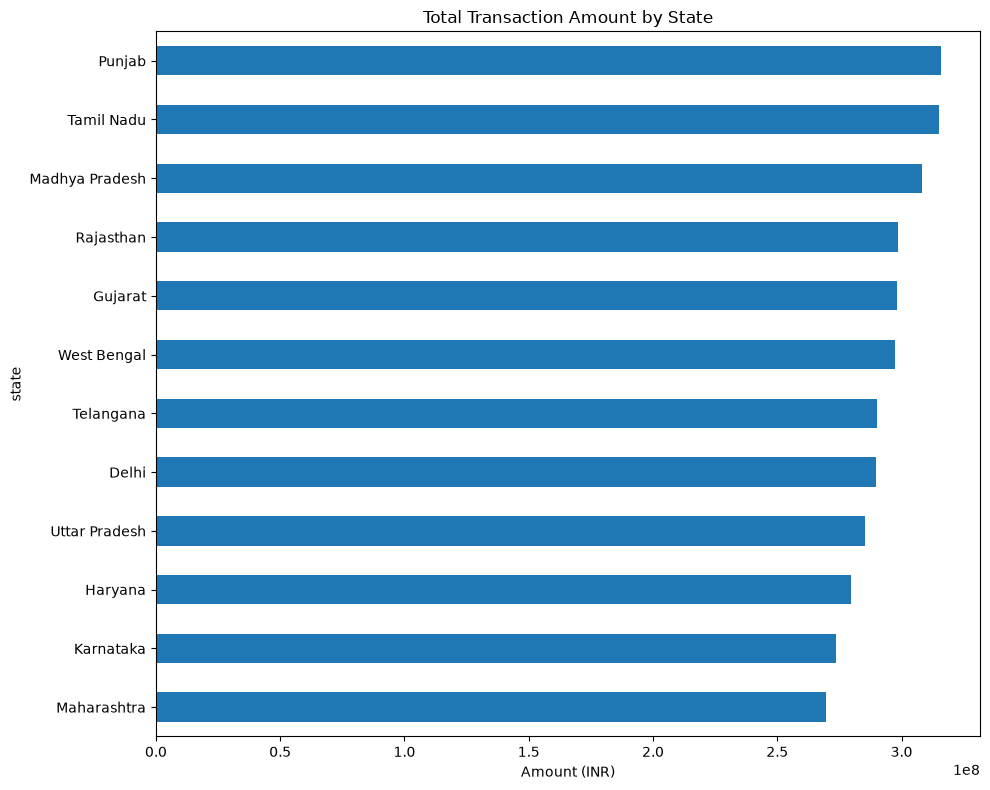

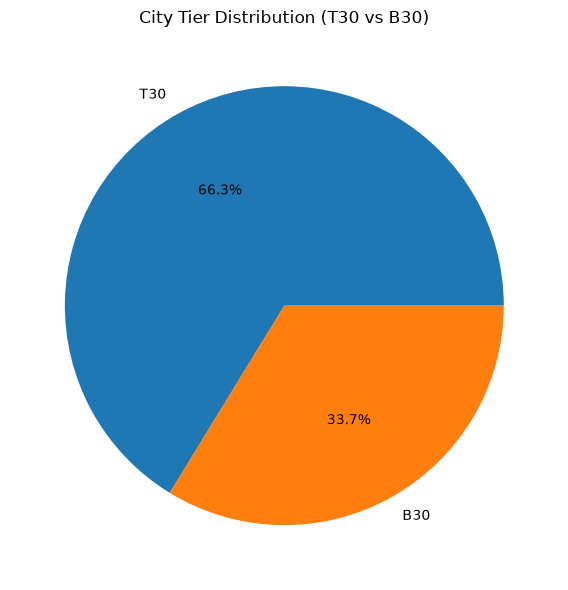

In [8]:
tx = pd.read_csv("../data/processed/investor_transactions_clean.csv")
state_sip = tx.groupby("state")["amount_inr"].sum().sort_values()
plt.figure(figsize=(10, 8))
state_sip.plot.barh()
plt.title("Total Transaction Amount by State"); plt.xlabel("Amount (INR)")
plt.tight_layout()
plt.savefig("../reports/charts/06a_state_bar.png", dpi=120); plt.show()

tx["city_tier"].value_counts().plot.pie(autopct="%1.1f%%", figsize=(6,6),
    title="City Tier Distribution (T30 vs B30)")
plt.ylabel(""); plt.tight_layout()
plt.savefig("../reports/charts/06b_city_tier.png", dpi=120); plt.show()

## Chart7 - Folio count growth

In [9]:
folio = pd.read_csv(RAW / "06_industry_folio_count.csv")
folio["month"] = pd.to_datetime(folio["month"])
fig = px.line(folio, x="month", y="total_folios_crore",
              title="Folio Count Growth (Jan 2022 - Dec 2025)", markers=True)
start, end = folio.iloc[0], folio.iloc[-1]
fig.add_annotation(x=str(start["month"].date()), y=start["total_folios_crore"],
                   text=f"Start: {start['total_folios_crore']:.2f} Cr", showarrow=True, ay=40)
fig.add_annotation(x=str(end["month"].date()), y=end["total_folios_crore"],
                   text=f"Latest: {end['total_folios_crore']:.2f} Cr", showarrow=True, ay=-40)
fig.update_layout(height=500)
fig.write_image("../reports/charts/07_folio_growth.png")
fig.show()

## Chart8-Correlation Matrix

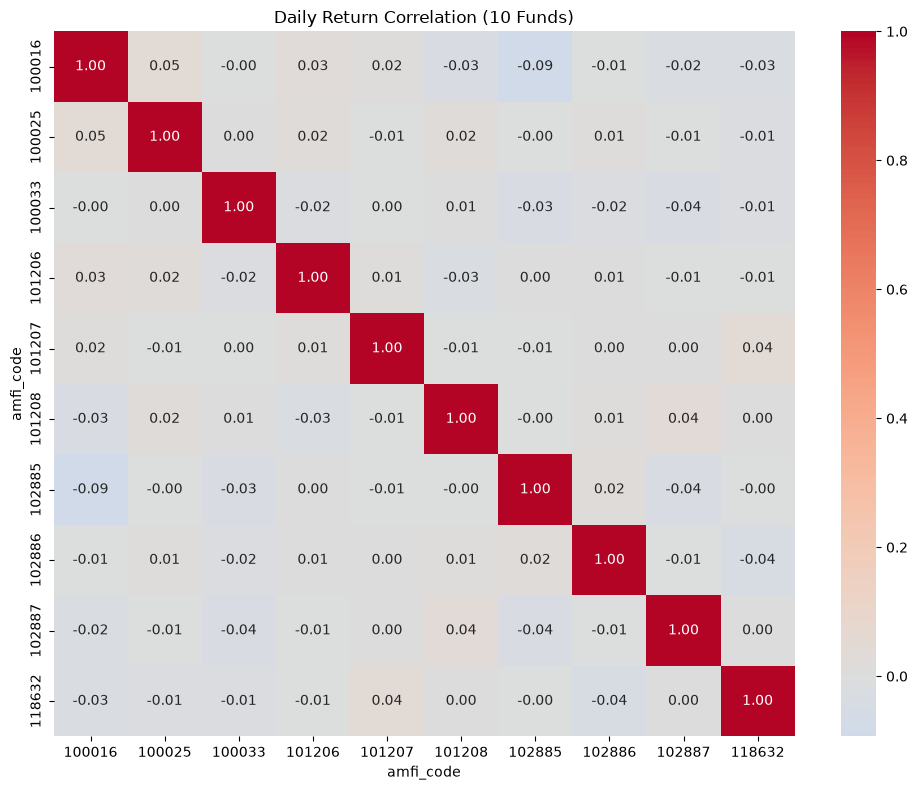

In [11]:
nav2 = nav.sort_values(["amfi_code", "date"]).copy()
nav2["ret"] = nav2.groupby("amfi_code")["nav"].pct_change()
ten = nav2["amfi_code"].unique()[:10]
wide = nav2[nav2["amfi_code"].isin(ten)].pivot_table(
    index="date", columns="amfi_code", values="ret")
corr = wide.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Daily Return Correlation (10 Funds)")
plt.tight_layout()
plt.savefig("../reports/charts/08_correlation.png", dpi=120); plt.show()

## Chart9-Sector donut

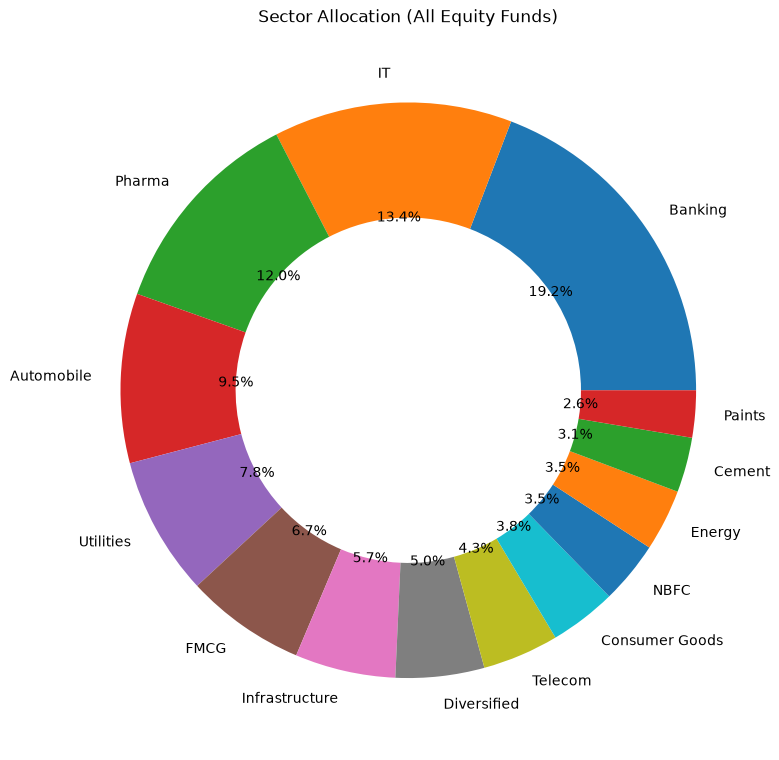

In [10]:
holdings = pd.read_csv(RAW / "09_portfolio_holdings.csv")
sector = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 8))
plt.pie(sector, labels=sector.index, autopct="%1.1f%%",
        wedgeprops=dict(width=0.4))
plt.title("Sector Allocation (All Equity Funds)")
plt.tight_layout()
plt.savefig("../reports/charts/09_sector_donut.png", dpi=120); plt.show()

# 10 Key EDA Findings

1. **NAV growth across the board** — All 40 schemes trend upward 2022–2026, with a visible dip during the 2024 correction. *(Chart 1)*
2. **SBI dominates AUM** — SBI Mutual Fund leads at ~₹12.5L Cr, ahead of ICICI and HDFC. *(Chart 2)*
3. **SIP inflows hit record highs** — Monthly SIP grew from ~₹11,500 Cr (2022) to ₹31,002 Cr in Dec 2025. *(Chart 3)*
4. **Liquid funds see the largest flows** — Liquid funds consistently show the highest net inflows. *(Chart 4)*
5. **Young investors dominate** — The 26–35 age group is 41.1% of investors. *(Chart 5)*
6. **Gender gap** — Male investors are 66.5% of transactions vs 33.5% female. *(Chart 5)*
7. **Geographic concentration** — Punjab, Tamil Nadu, and Madhya Pradesh lead in transaction value. *(Chart 6)*
8. **T30 cities lead** — 66.3% of transactions from T30 cities vs 33.7% B30. *(Chart 6)*
9. **Folio base nearly doubled** — Total folios grew from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025). *(Chart 7)*
10. **Diverse fund types** — The 10 sampled funds show near-zero cross-correlation, indicating a mix of equity and debt/liquid funds; sector-wise, Banking (19.2%) and IT (13.4%) dominate equity holdings. *(Charts 8, 9)*